<style>
  body {
    margin: 0;
    padding: 0;
    font-family: Arial, sans-serif;
  }

  /* Linha das logos usando table layout */
  .cover-header {
    display: table;
    width: 100%;
    margin-top: 20px;
    table-layout: fixed;
  }

  .cover-header .left{
    display: table-cell;
    width: 20%;
    vertical-align: middle;
    text-align: center;
  }
  .cover-header .right {
    display: table-cell;
    width: 30%;
    vertical-align: middle;
    text-align: center;
  }

  .cover-header .center {
    display: table-cell;
    width: 50%;
    text-align: center;
    vertical-align: middle;
  }

  .cover-header img {
    max-height: 55px;
    width: auto;
    display: inline-block;
  }

  /* Texto institucional embaixo das logos */
  .cover-center {
    text-align: center;
    margin-top: 20px;
    vertical-align: middle;
  }

  .cover-center p {
    text-align: center;
    vertical-align: middle;
    margin: 0;
    font-weight: 700;
    line-height: 1.4;
    font-size: 16px;
  }

  /* Título e autor */
  .cover-title {
    margin-top: 120px;
    text-align: center;
  }

  .cover-title h1 {
    font-size: 28px;
    margin-bottom: 60px;
  }

  .cover-title .author {
    font-size: 18px;
    margin-top: 160px; /* nome bem mais abaixo */
  }

  /* Rodapé fixo */
  .cover-footer {
    position: absolute;
    bottom: 30px;
    left: 0;
    width: 100%;
    text-align: center;
    font-size: 14px;
  }

  .cover-footer {
  position: absolute;
  bottom: 30px;
  left: 0;
  width: 100%;
  text-align: center;
  font-size: 14px;
}

</style>

<div class="cover-header">
  <div class="left">
    <img src="Imagens/logo_virtus2.png" alt="Logo VIRTUS">
  </div>
  <div class = "center"></div>
  <div class="right">
    <img src="Imagens/logo_ufcg.png" alt="Logo UFCG">
  </div>
</div>

<div class="cover-center">
  <p>
    UNIVERSIDADE FEDERAL DE CAMPINA GRANDE<br>
    CENTRO DE CIÊNCIAS E TECNOLOGIA<br>
    CENTRO DE ENGENHARIA ELÉTRICA E INFORMÁTICA<br>
    CENTRO DE COMPETÊNCIAS EMBRAPII VIRTUS-CC
  </p>
</div>

<div class="cover-title">
  <h1>Conversão de Taxa de Amostragem</h1>
  <p class="author">Jezrael Pereira Filgueiras</p>
</div>

<div class="cover-footer">
  Campina Grande, 12 de Março de 2026
</div>

<div style="page-break-after: always;"></div>

In [63]:
import numpy as np
from fractions import Fraction
import matplotlib.pyplot as plt
from scipy.signal import decimate, group_delay
import math
from scipy import signal
import sys
sys.path.append('./pds_utils')
import pds_utils as pds

np.random.seed(42)
plt.style.use('seaborn-v0_8')

In [64]:
def decimate_fft(x, N, smooth = True):
    """ Decimate a signal by a factor of N using FFT.
    Parameters
    ----------
    x : array_like
        Input signal.
    N : int
        Decimation factor.
    n : int, optional
        Number of coefficients of the low-pass filter. If None, it will be set to 30*N.
    Returns
    -------
    y : ndarray
        Decimated signal.
    """
    y = []
    N_out = math.ceil(len(x) / N)


    #print(f"Decimation factor: {N}, Output length: {N_out}")
    X = np.fft.fftshift(np.fft.fft(x))
    f_0 = len(x)//2
    start_idx = f_0 - N_out//2


    X_decimate = X[start_idx : start_idx+N_out]
        
    #print(f"Decimated FFT length: {len(X_decimate)}")
    X_decimate = np.fft.ifftshift(X_decimate)
    x_decimate = np.fft.ifft(X_decimate)

    return x_decimate / N

def decimate_overlap_save(x, N, block_size=2048, overlap_factor=4):
    """
    Decimates a signal by a factor of N using the overlap-save method with FFT-based decimation.
    Paramters
    ----------
    x : ndarray
        Input signal.
    N : int
        Decimation factor.
    block_size : int, optional
        Size of each processing block. Should be a multiple of N for best performance.
    overlap_factor : int, optional
        Factor determining the overlap between blocks.
    Returns
    -------
    y : ndarray
        Decimated signal.
    """
    if block_size % N != 0:
        block_size = (block_size // N) * N
    
    overlap = block_size // overlap_factor
    overlap = (overlap // N) * N
    step = block_size - 2 * overlap  
    
    num_steps = int(np.ceil(len(x) / step))
    total_padding_end = (num_steps * step) - len(x) + overlap
    
    x_padded = np.pad(x, (overlap, total_padding_end), mode='reflect')
    
    y_final = []
    
    discard_out = overlap // N
    step_out = step // N

    for i in range(num_steps):
        start = i * step
        block = x_padded[start : start + block_size]
        
        y_block = decimate_fft(block, N)
        
        y_segment = y_block[discard_out : discard_out + step_out]
        y_final.append(y_segment)
    
    result = np.concatenate(y_final)
    
    return np.real(result[:int(np.ceil(len(x)/N))])

def upsample_fft(x, L):
    """
    Upsamples a signal by a factor of L using FFT-based interpolation.
    Parameters
    ----------
    x : array_like
        Input signal.
    L : int
        Upsampling factor.
    Returns
    -------
    y : ndarray
        Upsampled signal.
    """
    n = len(x)
    N_out = n * L
    X = np.fft.fft(x)
    
    Y = np.zeros(N_out, dtype=complex)

    mid = (n + 1) // 2
    Y[:mid] = X[:mid]
    
    if n % 2 == 0:
        nyquist_idx = n // 2
        Y[nyquist_idx] = X[nyquist_idx] / 2
        Y[N_out - nyquist_idx] = X[nyquist_idx] / 2
        Y[N_out - nyquist_idx + 1:] = X[nyquist_idx + 1:]
    else:
        Y[N_out - (n - mid):] = X[mid:]
        
    return np.fft.ifft(Y) * L

def upsample_overlap_save(x, L, block_size=1024, overlap_factor=4):
    """
    Upsamples a signal by a factor of L using FFT-based interpolation with overlap-save method.
    Parameters    
    ----------
    x : ndarray
        Input signal.
    L : int
        Upsampling factor.
    block_size : int, optional
        Size of each processing block.
    overlap_factor : int, optional
        Factor determining the overlap between blocks.

    Returns
    -------
    y : ndarray
        Upsampled signal.
    """
    overlap = block_size // overlap_factor
    step = block_size - 2 * overlap 
    
    x_padded = np.pad(x, (overlap, block_size), mode='reflect')
    
    y_final = []
    overlap_out = overlap * L
    step_out = step * L

    for i in range(0, len(x), step):
        block = x_padded[i : i + block_size]
        
        y_block = upsample_fft(block, L)
        
        y_segment = y_block[overlap_out : overlap_out + step_out]
        y_final.append(y_segment)
    
    result = np.concatenate(y_final)
    return np.real(result[:L * len(x)])


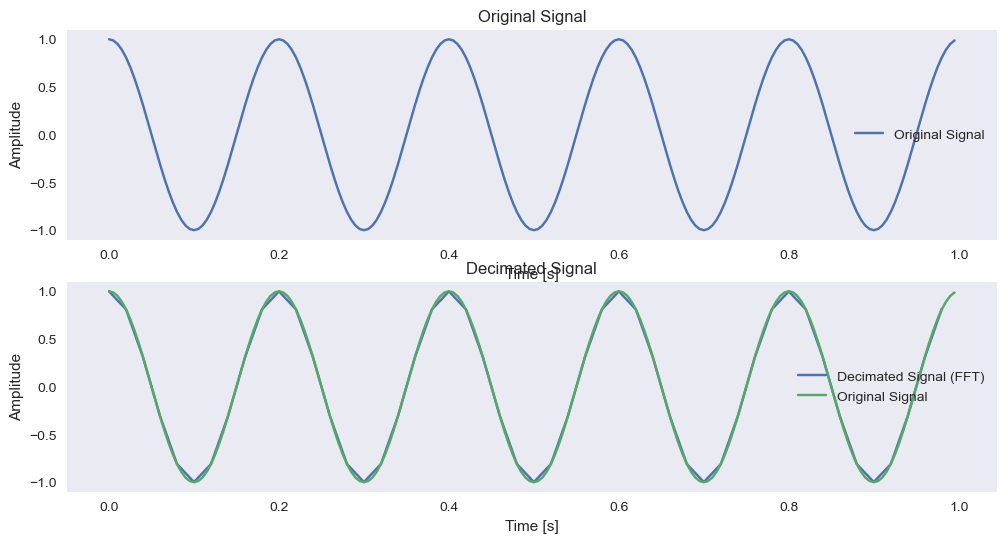

In [65]:
f_orig = 200
L = 4              
f_sinal = 5        
T = 1

n = np.arange(0, T, 1/f_orig)
x_n = np.cos(2 * np.pi * f_sinal * n) #+ 0.5 * np.cos(2 * np.pi * 10 * n)
#x_decimate = decimate_fft(x_n, 4)
x_decimate = decimate_overlap_save(x_n, 4, block_size=2048)
n_decimate = np.linspace(0, T, len(x_decimate), endpoint=False)

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(n, x_n, label='Original Signal')
plt.title('Original Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid()
plt.legend()

plt.subplot(2, 1, 2)

plt.plot(n_decimate, x_decimate, label='Decimated Signal (FFT)')
plt.plot(n, x_n, label='Original Signal')
plt.title('Decimated Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid()
plt.legend()

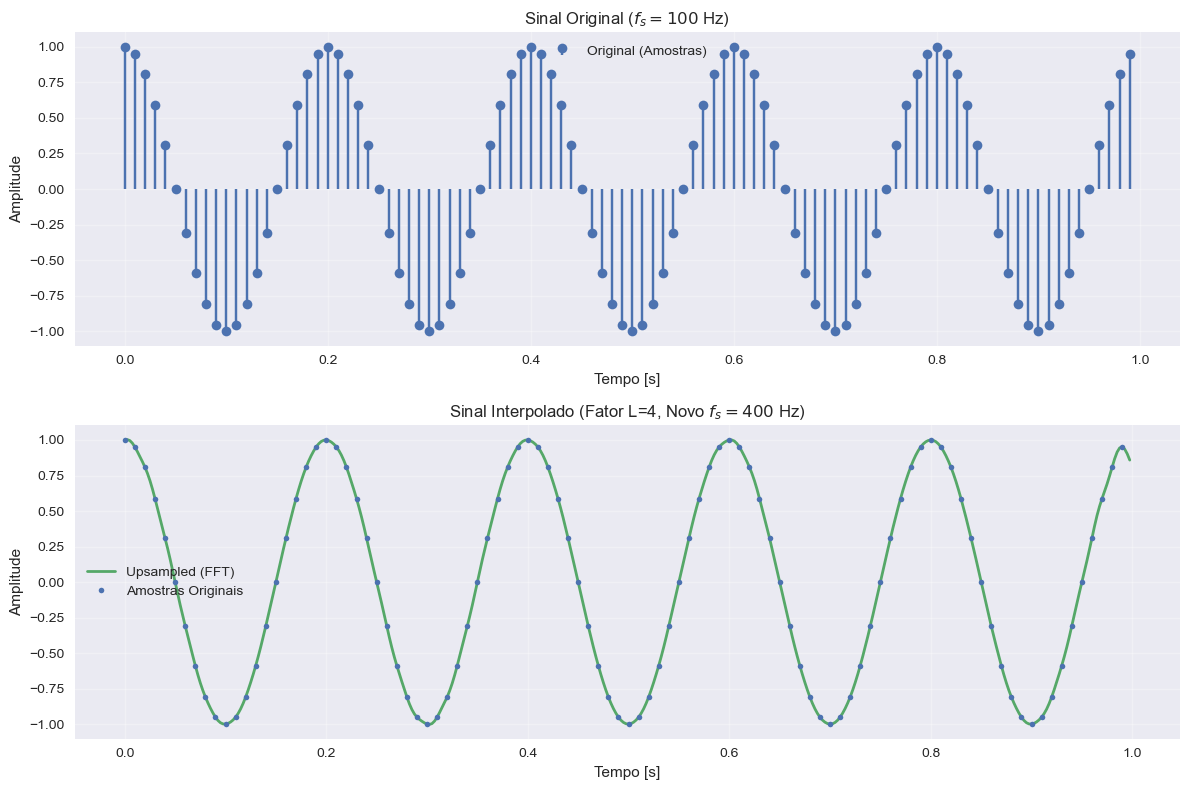

In [66]:
f_orig = 100       
L = 4              
f_sinal = 5        
T = 1              

n = np.arange(0, T, 1/f_orig)
x_n = np.cos(2 * np.pi * f_sinal * n)

x_upsampled = upsample_overlap_save(x_n, L, block_size=64, overlap_factor=4)

n_upsampled = np.linspace(0, T, len(x_upsampled), endpoint=False)


plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.stem(n, x_n, linefmt='C0-', markerfmt='C0o', basefmt=' ',
         label='Original (Amostras)')
plt.title(f'Sinal Original ($f_s = {f_orig}$ Hz)')
plt.xlabel('Tempo [s]')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(n_upsampled, x_upsampled, color='C1', linewidth=2, 
         label='Upsampled (FFT)')
plt.plot(n, x_n, 'C0o', markersize=4, label='Amostras Originais')

plt.title(f'Sinal Interpolado (Fator L={L}, Novo $f_s = {f_orig * L}$ Hz)')
plt.xlabel('Tempo [s]')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [67]:
def resample_fft(x, r, block_size=2048):
    """
    Muda a taxa de amostragem de um sinal por um fator r = L/M.
    
    Parameters
    ----------
    x : array_like
        Sinal de entrada.
    r : float
        Fator de reamostragem (ex: 1.5, 0.75, 2).
    """
    frac = Fraction(r).limit_denominator()
    L, M = frac.numerator, frac.denominator
    
    #print(f"Reamostragem r={r} -> L={L}, M={M}")
    if L > 1:
        x_L = upsample_overlap_save(x, L, block_size=block_size)
    else:
        x_L = x  
    if M > 1:
        
        y = decimate_overlap_save(x_L, M, block_size=block_size)
    else:
        y = x_L
        
    return y

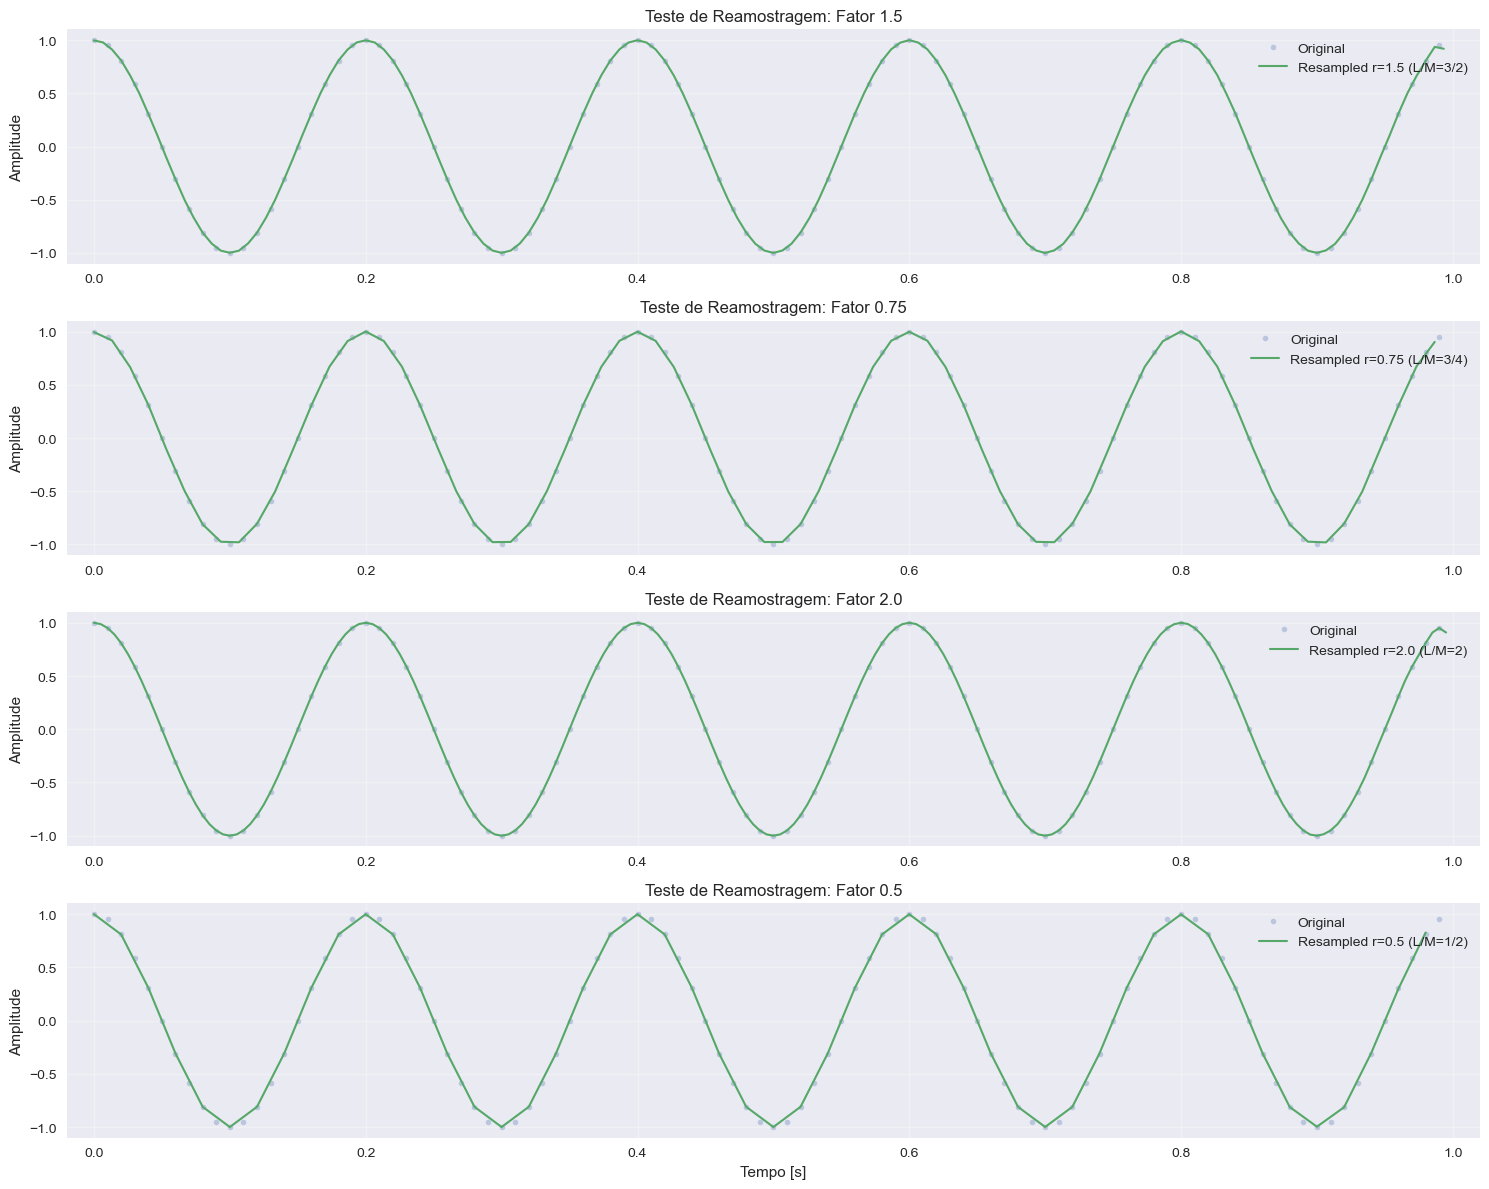

In [68]:
fs_base = 100  
duration = 1  
f_sinal = 5   

t = np.arange(0, duration, 1/fs_base)
x = np.cos(2 * np.pi * f_sinal * t)

taxas = [1.5, 0.75, 2.0, 0.5]

plt.figure(figsize=(15, 12))

for i, r in enumerate(taxas):
    y = resample_fft(x, r, block_size=512)
    
    fs_new = fs_base * r
    t_new = np.linspace(0, duration, len(y), endpoint=False)

    
    plt.subplot(len(taxas), 1, i + 1)
    plt.plot(t, x, 'C0o', markersize=4, alpha=0.3, label='Original')
    
    label_res = f'Resampled r={r} (L/M={Fraction(r).limit_denominator()})'
    plt.plot(t_new, y, 'C1-', linewidth=1.5, label=label_res)
    
    plt.title(f'Teste de Reamostragem: Fator {r}')
    plt.ylabel('Amplitude')
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper right')
    
   
    plt.xlim(-0.02, duration + 0.02) 

plt.xlabel('Tempo [s]')
plt.tight_layout()
plt.show()

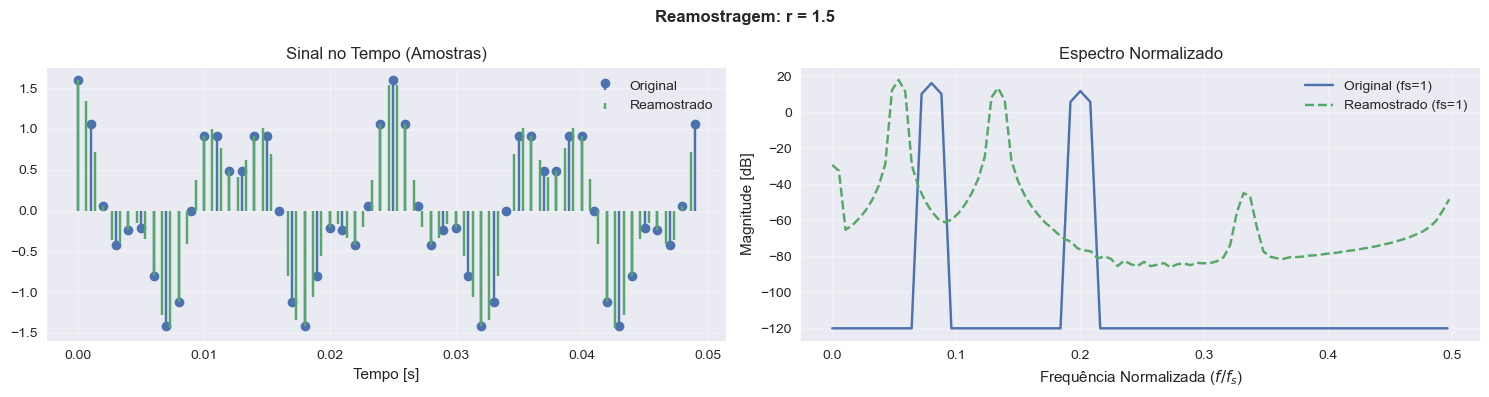

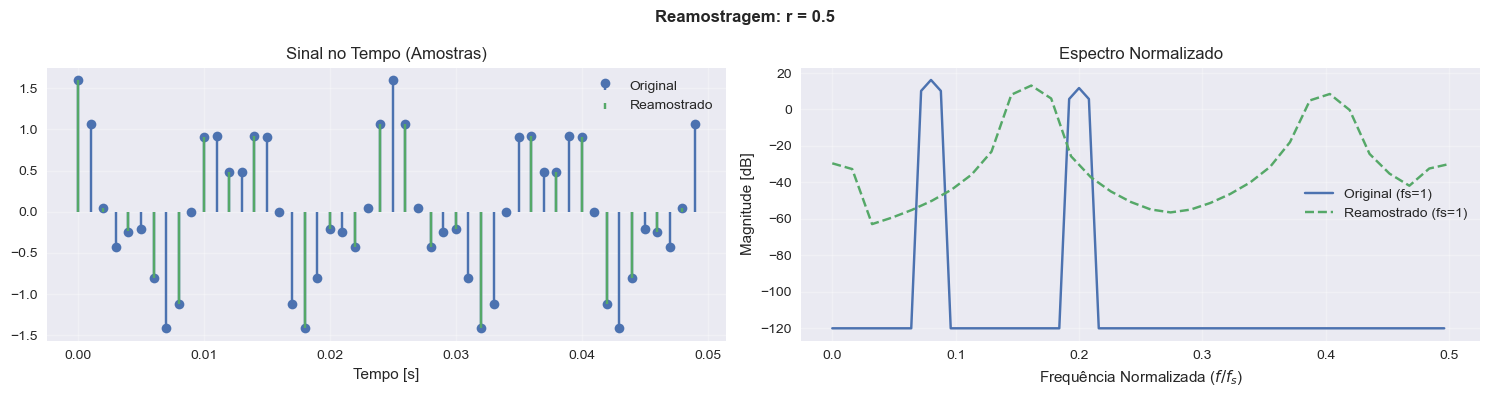

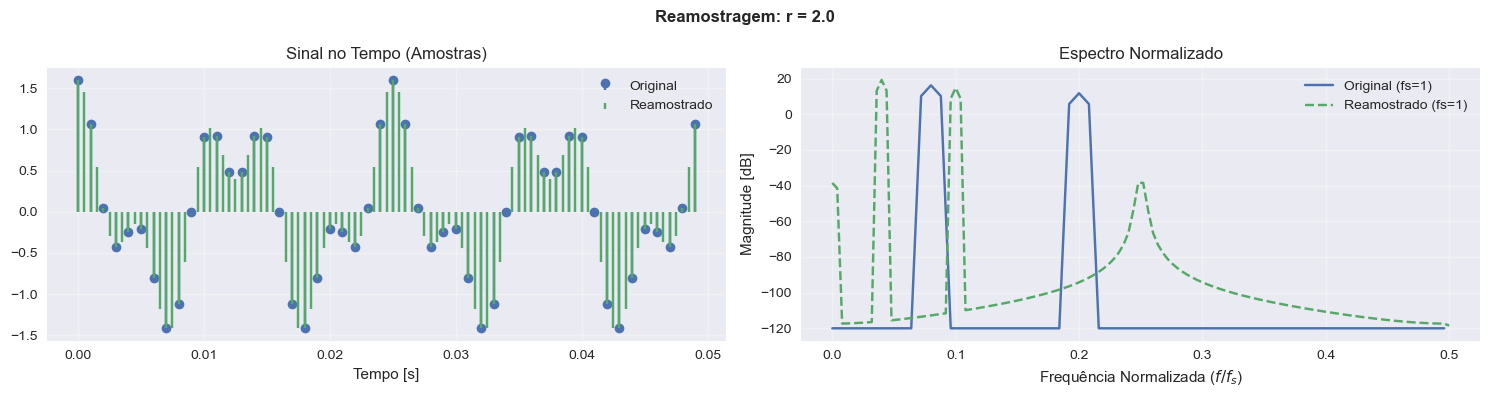

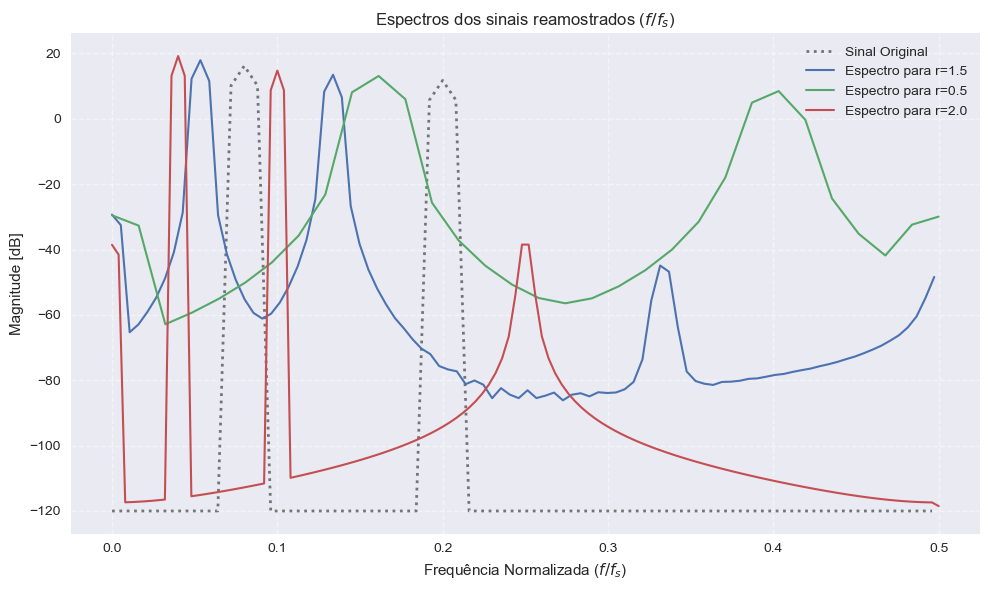

In [70]:
fs_orig = 1000.0
T = 0.5
f1, f2 = 80.0, 200.0 

t = np.arange(0, T, 1/fs_orig)
x_original = np.cos(2 * np.pi * f1 * t) + 0.6 * np.cos(2 * np.pi * f2 * t)

taxas = [1.5, 0.5, 2.0]
espectros_comparativos = []

for r in taxas:
    
    y_resampled = resample_fft(x_original, r, block_size=1024)
    
    fs_new = fs_orig * r
    t_new = np.arange(len(y_resampled)) / fs_new
    
    
    fig, (ax_t, ax_f) = plt.subplots(1, 2, figsize=(15, 4))
    fig.suptitle(f"Reamostragem: r = {r}", fontsize=12, fontweight='bold')
    
    
    n_show = 50
    ax_t.stem(t[:n_show], x_original[:n_show], linefmt='C0-', markerfmt='C0o', 
              label='Original', basefmt=" ")

    mask_y = t_new <= t[n_show-1]
    ax_t.stem(t_new[mask_y], y_resampled[mask_y], linefmt='C1-', markerfmt='C1x', 
              label='Reamostrado', basefmt=" ")
    ax_t.set_title("Sinal no Tempo (Amostras)")
    ax_t.set_xlabel("Tempo [s]")
    ax_t.legend()
    ax_t.grid(True, alpha=0.3)
    
    
    f_norm_x, p_x = signal.welch(x_original, fs=1.0, nperseg=len(x_original)//4)
    f_norm_y, p_y = signal.welch(y_resampled, fs=1.0, nperseg=len(y_resampled)//4)
    
    ax_f.plot(f_norm_x, 10*np.log10(p_x + 1e-12), label='Original (fs=1)')
    ax_f.plot(f_norm_y, 10*np.log10(p_y + 1e-12), label='Reamostrado (fs=1)', 
              linestyle='--')
    ax_f.set_title("Espectro Normalizado")
    ax_f.set_xlabel("Frequência Normalizada ($f/f_s$)")
    ax_f.set_ylabel("Magnitude [dB]")
    ax_f.legend()
    ax_f.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    
    espectros_comparativos.append((f_norm_y, p_y, r))

plt.figure(figsize=(10, 6))


f_orig_ref, p_orig_ref = signal.welch(x_original, fs=1.0, nperseg=len(x_original)//4)
plt.plot(f_orig_ref, 10*np.log10(p_orig_ref + 1e-12), 'k:', linewidth=2, 
         label='Sinal Original', alpha=0.5)

for f, p, r in espectros_comparativos:
    plt.plot(f, 10*np.log10(p + 1e-12), label=f'Espectro para r={r}', linewidth=1.5)

plt.title("Espectros dos sinais reamostrados ($f/f_s$)")
plt.xlabel("Frequência Normalizada ($f/f_s$)")
plt.ylabel("Magnitude [dB]")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()